In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')

In [11]:
param_dict = {
        'instrument_id': '511090',
        'name': f'delta_v1',
        'stride': 1,

        'short_window': 300,
        'long_window': 600,
        'y_window': 600,
        'x_window': 600,

        'open_threshold': 3,  
        'open_confidence': 0,  

        'standard_num': 1000,

        'atr_multiplier': 4,
        'vol_window': 600,

        'adverse_cusum_threshold': 10,
        'adverse_cusum_drift': 3,

        'k_up': 3,
        'k_down': 3,
        "stop_tighten_start": 6000,
        'stop_tighten_step' : 60,
        'stop_tighten_factor': 0.9,
        'stop_tighten_floor': 0.75,
        'model_path': '/home/jovyan/work/model/delta_511090_volatility_16d_600_3.pkl'
        }

In [12]:
model_path = param_dict['model_path']
import joblib
model = joblib.load(model_path)
print(f"模型已加载: {model_path}")

模型已加载: /home/jovyan/work/model/delta_511090_volatility_16d_600_3.pkl


In [13]:
from delta import stg_demo 
tactic = stg_demo.StrategyDemo(model_path, param_dict)

In [14]:
# 单日回测测试
sys.path.append('/home/jovyan/base_demo')
import base_tool
snap_list = base_tool.snap_list_load(param_dict['instrument_id'], '20250911')

position_dict = {}
for snap in snap_list:
    tactic.on_snap(snap)
    position_dict[snap['time_mark']] = tactic.position_last

print(f"生成 {len(position_dict)} 个仓位信号")

生成 14402 个仓位信号


/home/jovyan/work/backtest_result/511090_20260401_delta_v1.pkl 已请求
日期 20260401 完成，盈亏: -14.60, 成交: 32次, 胜率: 0.0%, 平均持仓: 0.0快照
511090_20260402 no data
日期 20260402 无数据，跳过
/home/jovyan/work/backtest_result/511090_20260403_delta_v1.pkl 已请求
日期 20260403 完成，盈亏: 18.30, 成交: 20次, 胜率: 0.0%, 平均持仓: 0.0快照
511090_20260404 no data
日期 20260404 无数据，跳过
511090_20260405 no data
日期 20260405 无数据，跳过
511090_20260406 no data
日期 20260406 无数据，跳过
/home/jovyan/work/backtest_result/511090_20260407_delta_v1.pkl 已请求
日期 20260407 完成，盈亏: -11.10, 成交: 24次, 胜率: 0.0%, 平均持仓: 0.0快照
511090_20260408 no data
日期 20260408 无数据，跳过
/home/jovyan/work/backtest_result/511090_20260409_delta_v1.pkl 已请求
日期 20260409 完成，盈亏: 31.90, 成交: 20次, 胜率: 0.0%, 平均持仓: 0.0快照
511090_20260410 no data
日期 20260410 无数据，跳过
511090_20260411 no data
日期 20260411 无数据，跳过
511090_20260412 no data
日期 20260412 无数据，跳过
/home/jovyan/work/backtest_result/511090_20260413_delta_v1.pkl 已请求
日期 20260413 完成，盈亏: 1.80, 成交: 26次, 胜率: 0.0%, 平均持仓: 0.0快照
511090_20260414 no data
日期 20260414

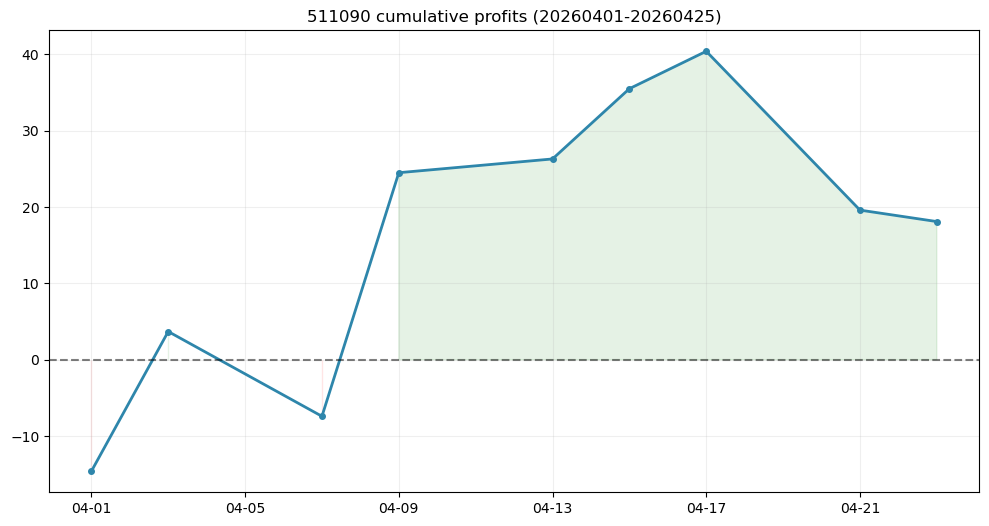

In [15]:
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from multi_day_backtest import backtest_multi_days
result_df = backtest_multi_days(
    instrument_id='511090',
    start_ymd="20260401",
    end_ymd="20260425",
    StrategyClass=stg_demo.StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    official=True
)

-> Python解释器: /opt/conda/bin/python
-> Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
spawn模式启动
-> 当前 Python 解释器: /opt/conda/bin/python
-> 从delta/train.py获取到 79 个有数据的交易日
-> 过滤后剩余 79 个有数据的交易日
-> 过滤掉 651 个无数据日期: ['20250101', '20250102', '20250103', '20250104', '20250105', '20250106', '20250107', '20250108', '20250109', '20250110']...
-> 回测标的: 511090 (20250101 - 20261231)
-> 任务分配: 共 79 天，使用 4 个核心并行计算...


[SpawnPoolWorker-48] 日期 20260305 完成 | 盈亏: 9.80 | 成交: 13次 | 胜率: 53.9% | 平均持仓: 808.9快照
[SpawnPoolWorker-46] 日期 20251103 完成 | 盈亏: -0.10 | 成交: 14次 | 胜率: 28.6% | 平均持仓: 736.3快照
[SpawnPoolWorker-45] 日期 20250901 完成 | 盈亏: -24.90 | 成交: 15次 | 胜率: 20.0% | 平均持仓: 547.8快照
[SpawnPoolWorker-47] 日期 20251229 完成 | 盈亏: 25.10 | 成交: 9次 | 胜率: 44.4% | 平均持仓: 830.3快照
[SpawnPoolWorker-48] 日期 20260309 完成 | 盈亏: 36.60 | 成交: 5次 | 胜率: 80.0% | 平均持仓: 1030.6快照
[SpawnPoolWorker-46] 日期 20251105 完成 | 盈亏: 15.40 | 成交: 12次 | 胜率: 41.7% | 平均持仓: 928.1快照
[SpawnPoolWorker-45] 日期 20250903 完成 | 盈亏: 67.50 | 成交: 10次 | 胜率: 70.0% | 平均持仓: 838.3快照
[SpawnPoolWorker-47] 日期 20251231 完成 | 盈亏: 11.70 | 成交: 6次 | 胜率: 33.3% | 平均持仓: 546.0快照
[SpawnPoolWorker-48] 日期 20260311 完成 | 盈亏: 13.70 | 成交: 11次 | 胜率: 54.5% | 平均持仓: 938.1快照
[SpawnPoolWorker-46] 日期 20251107 完成 | 盈亏: 0.80 | 成交: 10次 | 胜率: 60.0% | 平均持仓: 907.8快照
[SpawnPoolWorker-47] 日期 20260105 完成 | 盈亏: 12.30 | 成交: 10次 | 胜率: 60.0% | 平均持仓: 691.0快照
[SpawnPoolWorker-45] 日期 20250905 完成 | 盈亏: 3.00 | 成交: 12次 

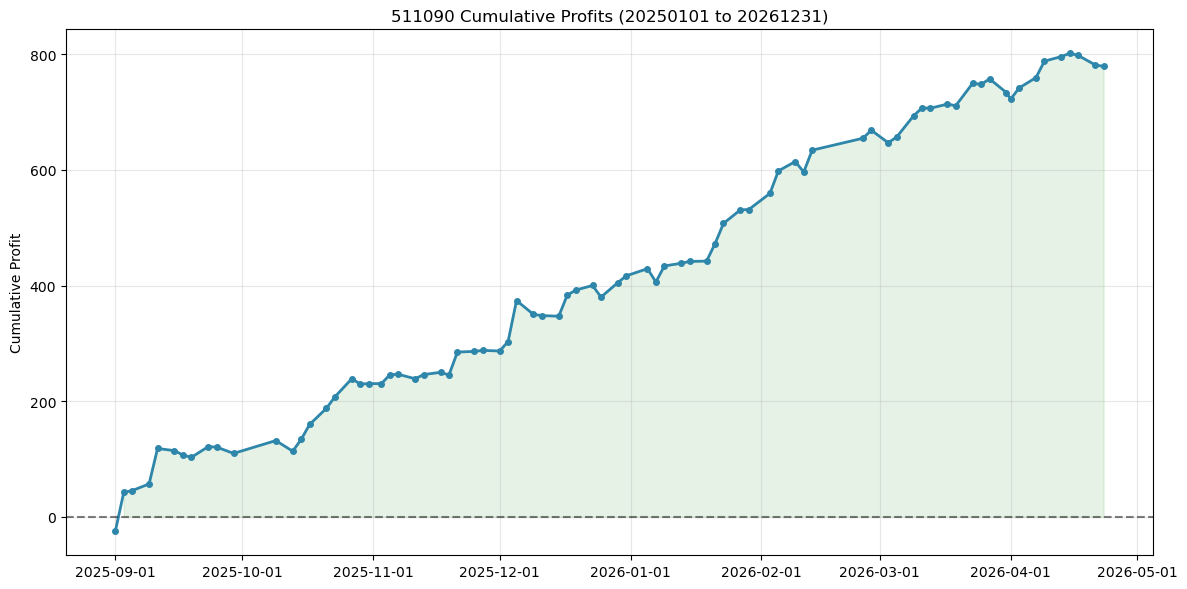


并行回测结果汇总:
{'测试天数': 79, '累计总盈亏': np.float64(779.0), '总成交次数': 939, '盈利交易次数': 387, '亏损交易次数': 552, '加权每手胜率%': np.float64(41.21), '日均盈亏': np.float64(9.86), '胜率(天)%': 65.82, '盈亏比(日均)': np.float64(2.04), '最大单日盈利': 70.9, '最大单日亏损': -24.9, '每笔交易平均盈利': np.float64(0.83), '加权平均持仓时间(快照)': np.float64(670.95)}


In [75]:
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest
from tools.multi_day_backtest import backtest_summary

result_df = run_parallel_backtest(
    instrument_id='511090',
    start_ymd="20250101",
    end_ymd="20261231",
    StrategyClass=stg_demo.StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    n_cores=4
)


print("\n并行回测结果汇总:")
summary = backtest_summary(result_df)
print(summary)

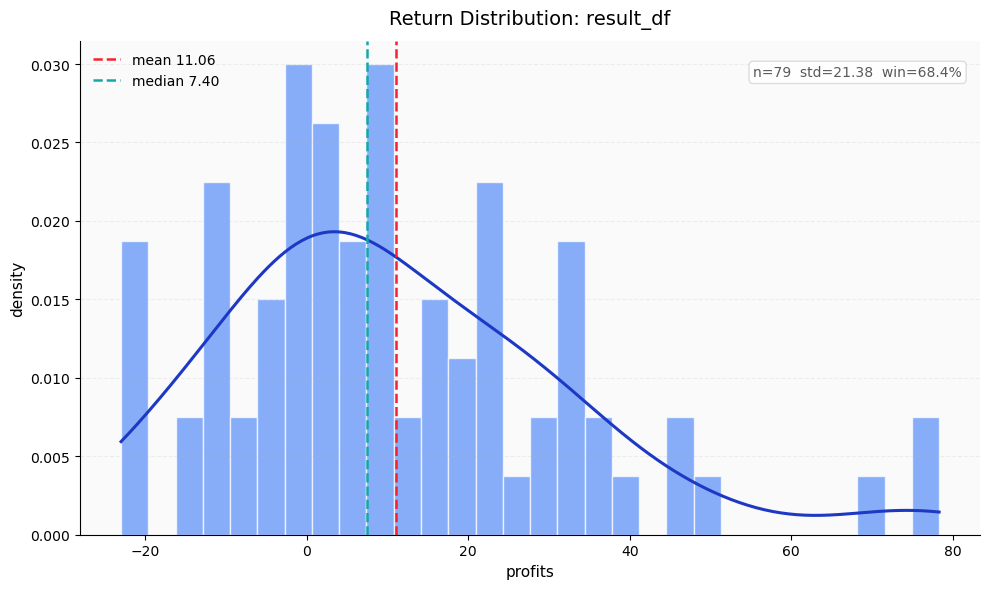

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Return Distribution: result_df'}, xlabel='profits', ylabel='density'>,
 {'count': 79,
  'mean': 11.060759493670886,
  'median': 7.4,
  'std': 21.378496371543108,
  'min': -23.0,
  'max': 78.3,
  'positive_ratio': 0.6835443037974683})

In [66]:
from tools import plot_return_distribution

plot_return_distribution(result_df = result_df)

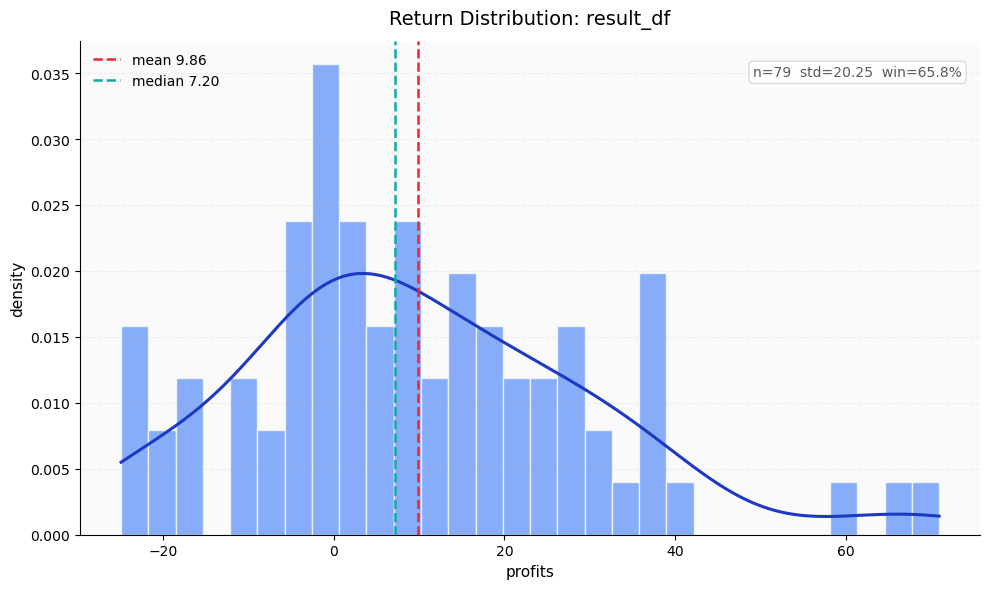

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Return Distribution: result_df'}, xlabel='profits', ylabel='density'>,
 {'count': 79,
  'mean': 9.860759493670885,
  'median': 7.2,
  'std': 20.24668645078219,
  'min': -24.9,
  'max': 70.9,
  'positive_ratio': 0.6582278481012658})

In [76]:
from tools import plot_return_distribution

plot_return_distribution(result_df = result_df)